# Benchmarking

In [1]:
import sys
import time
import torch
import gpytorch
import datasets
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import evaluation_metrics as em
import optuna

from optuna.pruners import MedianPruner
from mpl_toolkits.mplot3d import Axes3D
from sklearn.model_selection import KFold
from sklearn.linear_model import Ridge
from datasets import (
    load_dataset,
    min_max_scale_dataset
)

sys.path.insert(0, '/Users/gizemnurdal/Workspace/swim-meets-kans/pykan')
sys.path.insert(0, '/Users/gizemnurdal/Workspace/swim-meets-kans/sgkan')
from hkan.hkan import (
    Sigmoid, Gaussian, ReLU, Tanh, Softplus, Identity,
    make_hkan_layer, extend_hkan, set_tqdm_disable,
)
from kan import KAN # type: ignore
from sgkan import surrogate_guided_kan as sgkan
from sgkan import gaussian_process_models as gp
from sgkan import gp_swim_like_pairs as gs

torch.set_default_dtype(torch.float64)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")


/Users/gizemnurdal/miniconda3/envs/swim-meets-kans/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu


## Utilities Functions

In [2]:
def build_hkan_from_params(model_params, tqdm_disable=False):
    """
    Build an HKAN model from a list of layer-param dicts.

    Args:
        model_params: List of dicts with layer config (layer, n_vars_out, basis_fn, etc.)
        tqdm_disable: Disable progress bars in training

    Returns:
        Constructed HKAN model
    """
    # Ensure layers are processed in order (layer 0 first, then extended sequentially)
    params = sorted(model_params, key=lambda p: int(p["layer"]))
    model = None
    set_tqdm_disable(tqdm_disable)

    for p in params:
        layer_idx = int(p["layer"])
        n_vars_out = p["n_vars_out"]
        basis_fn = p["basis_fn"]
        n_basis = p.get("n_basis", 10)
        centers = p.get("centers", "random")
        reg = p.get("regressor", Ridge())

        if layer_idx == 0:
            # Create first layer with specified parameters
            model = make_hkan_layer(
                layer_idx=layer_idx,
                n_vars_out=n_vars_out,
                basis_fn=basis_fn,
                n_basis=n_basis,
                centers=centers,
                expanding_base_regressor=reg,
            )
        else:
            # Stack additional layers on top of existing model
            if model is None:
                raise ValueError("First layer (layer 0) must be provided before extending.")
            model = extend_hkan(
                model,
                layer_idx=layer_idx,
                n_vars_out=n_vars_out,
                basis_fn=basis_fn,
                n_basis=n_basis,
                centers=centers,
                expanding_base_regressor=reg,
            )
    return model

def fit_hkan(model, X_train, y_train):
    """Train HKAN model on training data and report elapsed time."""
    if model:
        start_time = time.time()
        model.fit(X_train, y_train)
        elapsed_time = time.time() - start_time
        print(f"\n✓ Training completed in {elapsed_time:.4f} seconds")

def predict_hkan(model, X_test):
    """Make predictions with HKAN model and report elapsed time."""
    if model:
        start_time = time.time()
        predictions = model.predict(X_test)
        elapsed_time = time.time() - start_time
        print(f"✓ Prediction completed in {elapsed_time:.4f} seconds")
        return predictions

In [3]:
def build_kan(width, grid=3, k=3, seed=42):
    """
    Build a KAN model with specified architecture.

    Args:
        width: List of layer widths, e.g., [2, 5, 1]
        grid: Grid size for spline basis
        k: Spline degree
        seed: Random seed for reproducibility

    Returns:
        KAN model instance
    """
    return KAN(width=width, grid=grid, k=k, seed=seed, device=device)

def fit_kan(model, X_train, y_train, X_test, y_test, steps=50, opt="Adam", lamb=0.01):
    """
    Train a KAN model with test data for validation.

    Args:
        model: KAN model instance
        X_train, y_train: Training data
        X_test, y_test: Test data for validation
        steps: Number of training iterations
        opt: Optimizer ("LBFGS" or "Adam")
        lamb: Regularization coefficient

    Returns:
        Trained KAN model
    """
    start_time = time.time()
    # Convert numpy arrays to torch tensors on the specified device
    X_train_tensor = torch.tensor(X_train, dtype=torch.float64, device=device)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float64, device=device)
    X_test_tensor = torch.tensor(X_test, dtype=torch.float64, device=device)
    y_test_tensor = torch.tensor(y_test, dtype=torch.float64, device=device)
    
    # Package data into KAN-compatible format
    dataset = {
        'train_input': X_train_tensor, 
        'train_label': y_train_tensor,
        'test_input': X_test_tensor,
        'test_label': y_test_tensor
    }
    model.fit(dataset, opt=opt, steps=steps, lamb=lamb)
    
    elapsed_time = time.time() - start_time
    print(f"\n✓ Training completed in {elapsed_time:.4f} seconds")
    return model

def predict_kan(model, X_test):
    """
    Make predictions with a KAN model.

    Args:
        model: Trained KAN model
        X_test: Input data for prediction

    Returns:
        Predictions as numpy array
    """
    start_time = time.time()
    # Convert to tensor, forward pass, then detach and convert back to numpy
    X_test_tensor = torch.tensor(X_test, dtype=torch.float64, device=device)
    predictions = model(X_test_tensor).detach().cpu().numpy()
    elapsed_time = time.time() - start_time
    print(f"✓ Prediction completed in {elapsed_time:.4f} seconds")
    return predictions

In [ ]:
# ─── Kernel utilities ──────────────────────────────────────────
# TODO: sin + sin kernel
def create_rbf_kernel(input_dim):
    """
    Create RBF kernel with ARD (automatic relevance determination).
    
    RBF: Choose it when you are confident the function is globally smooth with no 
    sharp local changes.
    """
    return gpytorch.kernels.ScaleKernel(
        gpytorch.kernels.RBFKernel(ard_num_dims=input_dim)
    )

def create_matern_kernel(input_dim, nu=2.5):
    """
    Create Matérn kernel with ARD (automatic relevance determination).
    
    Matérn ν=2.5: Choose it as the default for most real-world and physical data, 
    where the function is smooth enough to be differentiable but not so smooth that 
    infinitely many derivatives are guaranteed.
    """
    return gpytorch.kernels.ScaleKernel(
        gpytorch.kernels.MaternKernel(nu=nu, ard_num_dims=input_dim)
    )

def fit_sgkan(X_train, y_train, layer_configs, activation=torch.tanh, kernel=None, 
              lr=0.1, num_inducing=500, num_iters=100):
    """
    Train SGKAN (Surrogate-Guided KAN) model with optional custom kernel and GP hyperparameters.
    
    SGKAN uses a Gaussian process surrogate to guide the training of a KAN-like model,
    combining the interpretability of KAN with the uncertainty quantification of GPs.

    Args:
        X_train: Training input data (numpy array)
        y_train: Training target data (numpy array)
        layer_configs: List of dicts with layer configuration (width, M, G, T parameters)
        activation: Activation function (default: torch.tanh)
        kernel: GPyTorch kernel for the Gaussian process (default: RBF with ARD)
        lr: Learning rate for GP training (default: 0.1)
        num_inducing: Number of inducing points for sparse GP (default: 500)
        num_iters: Number of training iterations for GP (default: 100)

    Returns:
        Tuple of (layers, W_out) representing the trained SGKAN model
    """
    start_time = time.time()
    # Convert numpy arrays to torch tensors
    X_train_tensor = torch.tensor(X_train, dtype=torch.float64)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float64)
    
    # Build the SGKAN model with the specified configuration and GP hyperparameters
    layers, W_out = sgkan.build_sgkan(
        X_train_tensor, y_train_tensor, layer_configs, 
        activation=activation, kernel=kernel,
        lr=lr, num_inducing=num_inducing, num_iters=num_iters
    )
    
    elapsed_time = time.time() - start_time
    print(f"\n✓ Training completed in {elapsed_time:.4f} seconds")
    return layers, W_out

def predict_sgkan(layers, W_out, X_test, activation=torch.tanh):
    """
    Make predictions with a trained SGKAN model.

    Args:
        layers: List of SGKAN layers from fit_sgkan
        W_out: Output weights from fit_sgkan
        X_test: Input data for prediction (numpy array)
        activation: Activation function used during training (default: torch.tanh)

    Returns:
        Predictions as numpy array
    """
    start_time = time.time()
    # Convert to tensor and pass through the trained model
    X_test_tensor = torch.tensor(X_test, dtype=torch.float64)
    predictions = sgkan.predict_sgkan(layers, W_out, X_test_tensor, activation=activation).detach().numpy()
    elapsed_time = time.time() - start_time
    print(f"✓ Prediction completed in {elapsed_time:.4f} seconds")
    return predictions

In [5]:
def print_results(results):
    """
    Pretty-print evaluation results in a formatted table.
    
    Args:
        results: Dict with structure {'train': {'mae': float, 'rmse': float},
                                     'test': {'mae': float, 'rmse': float}}
    """
    # Format header row
    print(f"{'Metric':<15} {'Train':<20} {'Test':<20}")
    print("-" * 55)
    
    # Print MAE and RMSE metrics with scientific notation for readability
    for metric in ['mae', 'rmse']:
        train_val = results['train'][metric]
        test_val = results['test'][metric]
        print(f"{metric.upper():<15} {train_val:<20.6e} {test_val:<20.6e}")

def plot_3d_surface(dataset_name, X_test, y_test, y_pred):
    """
    Plot 3D surface comparison of predicted vs actual values.
    
    Creates side-by-side 3D surface plots for visual comparison of model predictions
    against ground truth. Useful for analyzing model behavior over the input space.

    Args:
        dataset_name: Name of the dataset (used in plot titles)
        X_test: Input test data with shape (n_samples, 2) for 2D input space
        y_test: Ground truth output values
        y_pred: Model predictions matching y_test shape
    """

    
    n_samples = len(X_test)
    # Reshape 1D arrays into 2D grids for surface plotting
    grid_size = int(np.sqrt(n_samples))
    
    fig = plt.figure(figsize=(14, 6))
    
    # Extract X1 and X2 dimensions and reshape for surface plotting
    X1 = X_test[:, 0].reshape(grid_size, grid_size)
    X2 = X_test[:, 1].reshape(grid_size, grid_size)
    
    # Plot predicted surface (left subplot)
    ax = fig.add_subplot(121, projection="3d")
    ax.plot_surface(X1, X2, y_pred.reshape(grid_size, grid_size), cmap="viridis")
    ax.set_title(f"{dataset_name} - Predicted")
    ax.set_xlabel("X1")
    ax.set_ylabel("X2")
    ax.set_zlabel("Y")
    
    # Plot actual surface (right subplot)
    ax = fig.add_subplot(122, projection="3d")
    ax.plot_surface(X1, X2, y_test.reshape(grid_size, grid_size), cmap="viridis")
    ax.set_title(f"{dataset_name} - Actual")
    ax.set_xlabel("X1")
    ax.set_ylabel("X2")
    ax.set_zlabel("Y")
    
    plt.tight_layout()
    plt.show()

## TF1 RESULTS

### HKAN

In [6]:
# Load TF1 dataset
tf1 = load_dataset("TF1")
tf1_x_train, tf1_x_test, tf1_y_train, tf1_y_test = tf1["train_input"], tf1["test_input"], tf1["train_label"], tf1["test_label"]

In [7]:
print("TF1 X_train shape:", tf1_x_train.shape)
print("TF1 X_test shape:", tf1_x_test.shape)
print("TF1 y_train range:", tf1_y_train.min(), tf1_y_train.max())
print("TF1 y_train mean:", tf1_y_train.mean())

TF1 X_train shape: (5000, 2)
TF1 X_test shape: (10000, 2)
TF1 y_train range: 0.00926302338925278 0.98881776725053
TF1 y_train mean: 0.5053805775495802


In [8]:
# TF1 model params
tf1_model_params = [
    {
        "layer": 0,
        "n_vars_out": 932,
        "basis_fn": Sigmoid(s=1),
        "n_basis": 2,
        "centers": "random_data_points",
        "regressor": Ridge(alpha=0.1),
    },
    {
        "layer": 1,
        "n_vars_out": 1,
        "basis_fn": Tanh(s=33),
        "n_basis": 13,
        "centers": "random_data_points",
        "regressor": Ridge(alpha=10),
    }
]
tf1_model = build_hkan_from_params(tf1_model_params)
tf1_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('expanding_layer_0', ...), ('connecting_layer_0', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,n_vars_out,932
,n_basis,2
,centers,'random_data_points'
,basis_fn,<hkan.hkan.Si...t 0x1655c0bd0>
,base_regressor,Ridge(alpha=0.1)
,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",0.1
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True


In [9]:
# Fit HKAN
fit_hkan(tf1_model,  tf1_x_train, tf1_y_train)
tf1_results = em.evaluate(
    tf1_model,
    tf1_x_train, tf1_y_train, tf1_x_test, tf1_y_test
)

Fitting connecting regressors: 100%|██████████| 1/1 [00:00<00:00,  2.86it/s]



✓ Training completed in 3.8057 seconds


In [10]:
print_results(tf1_results)

Metric          Train                Test                
-------------------------------------------------------
MAE             1.306771e-11         1.490351e-11        
RMSE            1.759482e-11         2.313418e-11        


In [11]:
tf1_y_test_pred = predict_hkan(tf1_model, tf1_x_test)

✓ Prediction completed in 2.2441 seconds


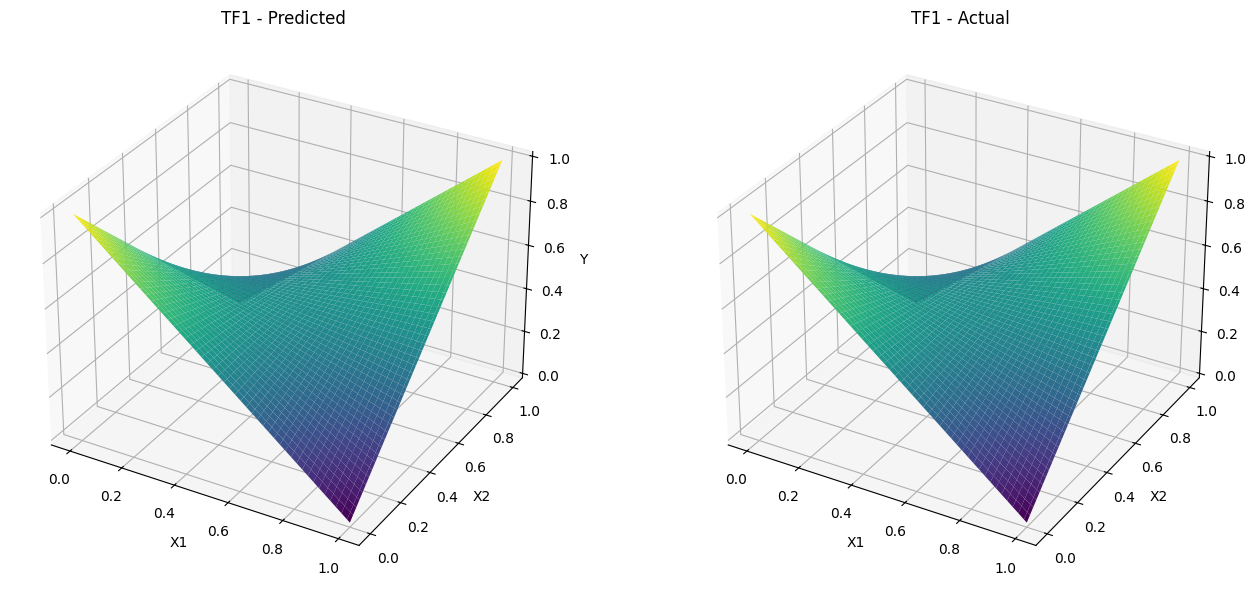

In [12]:
plot_3d_surface("TF1", tf1_x_test, tf1_y_test, tf1_y_test_pred)

### KAN

In [13]:
# Wrapper to add predict method for em.evaluate compatibility
class KANModel:
    def __init__(self, model):
        self.model = model
    def predict(self, X):
        X_tensor = torch.tensor(X, dtype=torch.float64, device=device)
        return self.model(X_tensor).detach().cpu().numpy()

In [14]:
def objective_kan(trial, X_train, y_train, X_test, y_test, n_splits=5):
    """
    Objective function for Optuna to find the best KAN architecture with K-Fold CV.
    
    Uses K-Fold Cross-Validation on training data to evaluate architectures robustly.
    Searches over predefined architecture set W from the HKAN paper.

    Only the network width configuration is searched. All other parameters 
    (grid, spline order k, optimizer, steps) are fixed at KAN defaults.

    The architecture set W is parameterised by n = X_train.shape[1]:
        W = {[n,1], [n,2,1], [n,n+1,1], [n,2n+1,1], [n,2,2,1],
             [n,n+1,2,1], [n,2n+1,2,1], [n,n+1,n+1,1],
             [n,2n+1,n+1,1], [n,2n+1,2n+1,1]}

    Args:
        trial: Optuna trial object
        X_train, y_train: Training data
        X_test, y_test: Test data for final evaluation
        n_splits: Number of folds for cross-validation (default: 5)

    Returns:
        float: Average validation RMSE across all folds (what Optuna minimizes)
    """
    n = X_train.shape[1]

    # Architecture search space W from the HKAN paper
    width_options = [
        [n, 1],
        [n, 2, 1],
        [n, n + 1, 1],
        [n, 2 * n + 1, 1],
        [n, 2, 2, 1],
        [n, n + 1, 2, 1],
        [n, 2 * n + 1, 2, 1],
        [n, n + 1, n + 1, 1],
        [n, 2 * n + 1, n + 1, 1],
        [n, 2 * n + 1, 2 * n + 1, 1],
    ]

    # Suggest architecture
    width_idx = trial.suggest_categorical("width_idx", list(range(len(width_options))))
    width = width_options[width_idx]

    # K-Fold Cross-Validation on training data
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    fold_val_rmses = []
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
        # Split into fold train/validation
        X_fold_train, X_fold_val = X_train[train_idx], X_train[val_idx]
        y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]
        
        # Build and train model with suggested architecture
        model = build_kan(width=width, grid=3, k=3, seed=42)
        fit_kan(model, X_fold_train, y_fold_train, 
                X_fold_val, y_fold_val,
                steps=100, opt="Adam", lamb=1e-3)
        
        # Evaluate on this fold's validation set
        results = em.evaluate(
            KANModel(model),
            X_fold_train, y_fold_train,
            X_fold_val, y_fold_val
        )
        fold_val_rmses.append(results['test']['rmse'])
    
    # Average validation RMSE across all folds (what Optuna minimizes)
    avg_val_rmse = float(np.mean(fold_val_rmses))
    
    # Also evaluate on the actual test set for reference (only once, not per fold)
    final_model = build_kan(width=width, grid=3, k=3, seed=42)
    fit_kan(final_model, X_train, y_train, X_test, y_test, steps=100, opt="Adam", lamb=1e-3)
    test_results = em.evaluate(KANModel(final_model), X_train, y_train, X_test, y_test)
    test_rmse = float(test_results['test']['rmse'])
    
    # Store test RMSE as user attribute (will appear in trials dataframe)
    trial.set_user_attr("test_rmse", test_rmse)
    trial.set_user_attr("val_rmse", avg_val_rmse)
    
    # Return validation RMSE for optimization
    return avg_val_rmse


# # --- Study setup with K-Fold CV -----------------------------------------------
# print("=" * 70)
# print("Optimizing KAN architecture with 5-Fold Cross-Validation on TF1")
# print("=" * 70)

# study = optuna.create_study(
#     direction='minimize',
#     sampler=optuna.samplers.GridSampler(
#         {"width_idx": list(range(10))}  # Exhaustive over all 10 architectures
#     ),
# )

# n = tf1_x_train.shape[1]
# width_options = [
#     [n, 1], [n, 2, 1], [n, n+1, 1], [n, 2*n+1, 1], [n, 2, 2, 1],
#     [n, n+1, 2, 1], [n, 2*n+1, 2, 1], [n, n+1, n+1, 1],
#     [n, 2*n+1, n+1, 1], [n, 2*n+1, 2*n+1, 1],
# ]

# study.optimize(
#     lambda trial: objective_kan(
#         trial, tf1_x_train, tf1_y_train, tf1_x_test, tf1_y_test, n_splits=5
#     ),
#     n_trials=10,
#     show_progress_bar=True,
# )

# # --- Results ---------------------------------------------------------------
# print("\n" + "=" * 70)
# print("Best trial results:")
# print("=" * 70)
# print(f"Best CV Validation RMSE: {study.best_value:.6f}")
# best_test_rmse = study.best_trial.user_attrs.get("test_rmse", "N/A")
# print(f"Best Test RMSE:          {best_test_rmse:.6f}" if isinstance(best_test_rmse, float) else f"Best Test RMSE: {best_test_rmse}")
# print(f"Best width_idx:          {study.best_params['width_idx']}")
# print(f"Best architecture:       {width_options[study.best_params['width_idx']]}")

# # Display all trials with both validation and test RMSE
# trials_df = study.trials_dataframe()
# print(f"\nAll {len(trials_df)} trials:")
# print(trials_df[['number', 'value', 'params_width_idx', 'user_attrs_val_rmse', 'user_attrs_test_rmse']].to_string())


# trials_df = trials_df.rename(columns={
#     "user_attrs_test_rmse": "test_rmse",
#     "user_attrs_val_rmse": "val_rmse",
# })
# trials_df['duration'] = trials_df['duration'].dt.total_seconds()
# trials_df.to_csv("data/tf1_kan_optuna_search.csv")

In [15]:
tf1_kan_optuna_search = pd.read_csv("data/tf1_kan_optuna_search.csv")
tf1_kan_optuna_search.sort_values("val_rmse")

,Unnamed: 0,number,value,datetime_start,datetime_complete,duration,params_width_idx,test_rmse,val_rmse,system_attrs_grid_id,system_attrs_search_space,state
0,0,0,0.161730,2026-06-05 16:26:16.717036,2026-06-05 16:27:12.793189,56.076153,2,0.172035,0.161730,0,"{'width_idx': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]}",COMPLETE
8,8,8,0.166398,2026-06-05 16:34:27.451048,2026-06-05 16:35:15.980925,48.529877,0,0.170176,0.166398,8,"{'width_idx': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]}",COMPLETE
2,2,2,0.168665,2026-06-05 16:28:15.929301,2026-06-05 16:29:18.376549,62.447248,4,0.194673,0.168665,2,"{'width_idx': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]}",COMPLETE
6,6,6,0.171583,2026-06-05 16:32:27.961908,2026-06-05 16:33:31.045600,63.083692,7,0.172921,0.171583,6,"{'width_idx': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]}",COMPLETE
4,4,4,0.174817,2026-06-05 16:30:27.248493,2026-06-05 16:31:23.874932,56.626439,1,0.179805,0.174817,4,"{'width_idx': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]}",COMPLETE
7,7,7,0.198986,2026-06-05 16:33:31.047117,2026-06-05 16:34:27.449475,56.402358,3,0.190309,0.198986,7,"{'width_idx': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]}",COMPLETE
5,5,5,0.245469,2026-06-05 16:31:23.877096,2026-06-05 16:32:27.960451,64.083355,6,0.175506,0.245469,5,"{'width_idx': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]}",COMPLETE
1,1,1,0.580494,2026-06-05 16:27:12.794782,2026-06-05 16:28:15.927739,63.132957,8,0.363583,0.580494,1,"{'width_idx': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]}",COMPLETE
9,9,9,0.612736,2026-06-05 16:35:15.982301,2026-06-05 16:36:21.414752,65.432451,5,0.528121,0.612736,9,"{'width_idx': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]}",COMPLETE
3,3,3,2.339897,2026-06-05 16:29:18.378220,2026-06-05 16:30:27.246974,68.868754,9,0.848483,2.339897,3,"{'width_idx': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]}",COMPLETE


In [16]:
# Create TF1 KAN model with architecture [2, 5, 1]
tf1_kan_model = build_kan(width=[2, 3, 1], grid=3, k=3, seed=42)

checkpoint directory created: ./model
saving model version 0.0


In [17]:
# Train TF1 KAN model
fit_kan(tf1_kan_model, tf1_x_train, tf1_y_train, tf1_x_test, tf1_y_test, steps=100, opt="Adam", lamb=1e-3)

tf1_kan_results = em.evaluate(
    KANModel(tf1_kan_model),
    tf1_x_train, tf1_y_train, tf1_x_test, tf1_y_test
)

| train_loss: 1.67e-01 | test_loss: 1.71e-01 | reg: 2.88e+01 | : 100%|█| 100/100 [00:22<00:00,  4.38

saving model version 0.1

✓ Training completed in 22.8308 seconds


In [18]:
print_results(tf1_kan_results)

Metric          Train                Test                
-------------------------------------------------------
MAE             1.261283e-01         1.289797e-01        
RMSE            1.681006e-01         1.720347e-01        


In [19]:
tf1_y_test_pred_kan = predict_kan(tf1_kan_model, tf1_x_test)

✓ Prediction completed in 0.0132 seconds


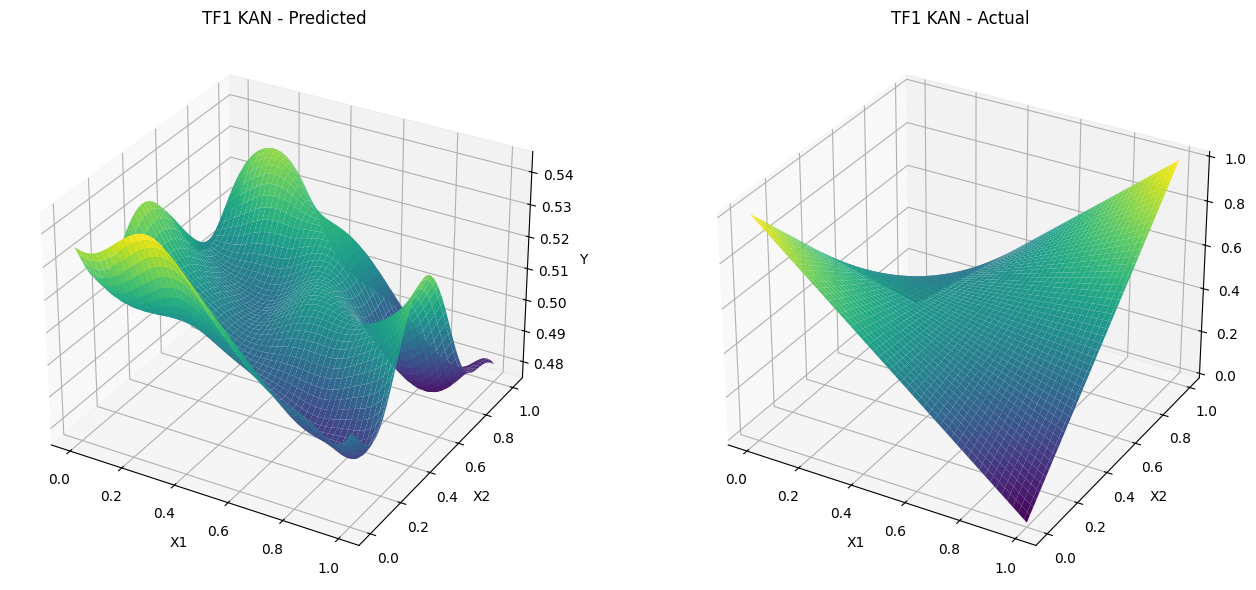

In [20]:
plot_3d_surface("TF1 KAN", tf1_x_test, tf1_y_test, tf1_y_test_pred_kan)

### GP (Gaussian Process Baseline)

In [21]:
def objective_gp(trial, X_train, y_train, X_test, y_test, n_splits=5):
    """
    Objective function for Optuna to find the best GP hyperparameters with K-Fold CV.
    
    Uses K-Fold Cross-Validation on training data to evaluate hyperparameter sets.
    Searches over learning rate, kernel type, and number of inducing points.

    Args:
        trial: Optuna trial object
        X_train, y_train: Training data
        X_test, y_test: Test data for final evaluation
        n_splits: Number of folds for cross-validation (default: 5)

    Returns:
        float: Average validation RMSE across all folds (what Optuna minimizes)
    """
    # Suggest hyperparameters
    lr = trial.suggest_float("lr", 1e-4, 1e-1, log=True)  # Learning rate
    kernel_type = trial.suggest_categorical("kernel", ["rbf", "matern"])  # Kernel type
    num_inducing = trial.suggest_int("num_inducing", 100, 500)  # Inducing points

    # Select kernel based on suggestion
    if kernel_type == "rbf":
        kernel = create_rbf_kernel(X_train.shape[1])
    else:  # matern
        kernel = create_matern_kernel(X_train.shape[1])
    
    # K-Fold Cross-Validation on training data
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    fold_val_rmses = []
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
        # Split into fold train/validation
        X_fold_train = X_train[train_idx]
        y_fold_train = y_train[train_idx]
        X_fold_val = X_train[val_idx]
        y_fold_val = y_train[val_idx]
        
        # Convert to torch tensors
        X_fold_train_t = torch.tensor(X_fold_train, dtype=torch.float64)
        y_fold_train_t = torch.tensor(y_fold_train, dtype=torch.float64)
        X_fold_val_t = torch.tensor(X_fold_val, dtype=torch.float64)
        y_fold_val_t = torch.tensor(y_fold_val, dtype=torch.float64)
        
        # Initialize GP model with suggested hyperparameters
        gp_model, gp_likelihood = gp.init_gp(X_fold_train_t, y_fold_train_t, kernel=kernel, num_inducing=num_inducing)
        
        # Train GP model
        gp_model, gp_likelihood = gp.train_gp(
            gp_model, gp_likelihood, X_fold_train_t, y_fold_train_t,
            num_iters=500, lr=lr
        )
        
        # Evaluate on this fold's validation set
        pred_mean, _ = gp.predict(gp_model, gp_likelihood, X_fold_val_t)
        rmse = em.compute_rmse(pred_mean, y_fold_val_t).item()
        fold_val_rmses.append(rmse)
    
    # Average validation RMSE across all folds (what Optuna minimizes)
    avg_val_rmse = float(np.mean(fold_val_rmses))
    
    # Also evaluate on the actual test set for reference
    X_train_t = torch.tensor(X_train, dtype=torch.float64)
    y_train_t = torch.tensor(y_train, dtype=torch.float64)
    X_test_t = torch.tensor(X_test, dtype=torch.float64)
    y_test_t = torch.tensor(y_test, dtype=torch.float64)
    
    gp_model_final, gp_likelihood_final = gp.init_gp(X_train_t, y_train_t, kernel=kernel, num_inducing=num_inducing)
    gp_model_final, gp_likelihood_final = gp.train_gp(
        gp_model_final, gp_likelihood_final, X_train_t, y_train_t,
        num_iters=500, lr=lr
    )
    
    pred_test, _ = gp.predict(gp_model_final, gp_likelihood_final, X_test_t)
    test_rmse = em.compute_rmse(pred_test, y_test_t).item()
    
    # Store test RMSE as user attribute
    trial.set_user_attr("test_rmse", test_rmse)
    trial.set_user_attr("val_rmse", avg_val_rmse)
    
    return avg_val_rmse


# # --- Study setup with K-Fold CV -----------------------------------------------
# print("=" * 70)
# print("Optimizing GP hyperparameters with 5-Fold Cross-Validation on TF1")
# print("=" * 70)

# study = optuna.create_study(direction='minimize')

# study.optimize(
#     lambda trial: objective_gp(trial, tf1_x_train, tf1_y_train, tf1_x_test, tf1_y_test, n_splits=5),
#     n_trials=10,
#     show_progress_bar=True,
# )

# # --- Results ---------------------------------------------------------------
# print("\n" + "=" * 70)
# print("Best trial results:")
# print("=" * 70)
# print(f"Best CV Validation RMSE: {study.best_value:.6f}")
# best_test_rmse = study.best_trial.user_attrs.get("test_rmse", "N/A")
# print(f"Best Test RMSE:          {best_test_rmse:.6f}" if isinstance(best_test_rmse, float) else f"Best Test RMSE: {best_test_rmse}")
# print(f"Best hyperparameters:")
# print(f"  lr:              {study.best_params['lr']:.6f}")
# print(f"  kernel:          {study.best_params['kernel']}")
# print(f"  num_inducing:    {study.best_params['num_inducing']}")

# # Display all trials
# trials_df = study.trials_dataframe()
# print(f"\nAll {len(trials_df)} trials:")
# print(trials_df[['number', 'value', 'params_lr', 'params_kernel', 'params_num_inducing', 'user_attrs_test_rmse']].to_string())

# trials_df = trials_df.rename(columns={
#     "user_attrs_test_rmse": "test_rmse",
#     "user_attrs_val_rmse": "val_rmse",
# })
# trials_df['duration'] = trials_df['duration'].dt.total_seconds()
# trials_df.to_csv("data/tf1_gp_optuna_search.csv")

In [23]:
tf1_gp_optuna_search = pd.read_csv("data/tf1_gp_optuna_search.csv")
tf1_gp_optuna_search.sort_values("val_rmse")

,Unnamed: 0,number,value,datetime_start,datetime_complete,duration,params_kernel,params_lr,params_num_inducing,test_rmse,val_rmse,state
7,7,7,0.022422,2026-06-05 17:35:15.994369,2026-06-05 17:38:33.753775,197.759406,matern,0.002930,388,0.028800,0.022422,COMPLETE
1,1,1,0.037381,2026-06-05 17:18:47.636064,2026-06-05 17:22:24.070913,216.434849,matern,0.001547,419,0.038695,0.037381,COMPLETE
6,6,6,0.037503,2026-06-05 17:34:06.755811,2026-06-05 17:35:15.992481,69.236670,rbf,0.001903,199,0.026927,0.037503,COMPLETE
5,5,5,0.063514,2026-06-05 17:32:31.884922,2026-06-05 17:34:06.754224,94.869302,matern,0.000803,183,0.066784,0.063514,COMPLETE
2,2,2,0.093754,2026-06-05 17:22:24.072938,2026-06-05 17:23:54.762745,90.689807,rbf,0.000629,247,0.127632,0.093754,COMPLETE
3,3,3,0.104000,2026-06-05 17:23:54.764267,2026-06-05 17:28:14.672790,259.908523,matern,0.000458,490,0.123434,0.104000,COMPLETE
9,9,9,0.139410,2026-06-05 17:39:27.264998,2026-06-05 17:41:00.338261,93.073263,rbf,0.000484,273,0.153379,0.139410,COMPLETE
0,0,0,0.261977,2026-06-05 17:16:27.463356,2026-06-05 17:18:47.634524,140.171168,rbf,0.000214,383,0.265265,0.261977,COMPLETE
8,8,8,0.292615,2026-06-05 17:38:33.755385,2026-06-05 17:39:27.263460,53.508075,matern,0.000176,122,0.294390,0.292615,COMPLETE
4,4,4,0.378702,2026-06-05 17:28:14.674359,2026-06-05 17:32:31.883234,257.208875,matern,0.000114,482,0.376157,0.378702,COMPLETE


Training Gaussian Process baseline on TF1
[DEBUG] Initialized SparseGPModel: X_train.shape=torch.Size([5000, 2]), num_inducing=388

Training GP...
[DEBUG] SparseGPModel and likelihood unfrozen (train mode)
[DEBUG] Training SparseGPModel: 500 iters, lr=0.00293, loss=ELBO
  Iter 100/500, Loss: 0.811568
  Iter 200/500, Loss: 0.772485
  Iter 300/500, Loss: 0.761316
  Iter 400/500, Loss: 0.755454
  Iter 500/500, Loss: 0.752304
[DEBUG] Training complete.
  Lengthscale: tensor([[0.4643, 0.4997]])
  Outputscale: 0.5420
  Noise: 0.693247
  Mean const: 0.2749
[DEBUG] SparseGPModel and likelihood frozen (eval mode)

Evaluating GP...
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
Metric          Train                Test                
-------------------------------------------------------
MAE             1.223987e-02         1.243799e-02        
RMSE            2.370240e-02         2.377613e-02        
[DEBUG] SparseGPModel and li

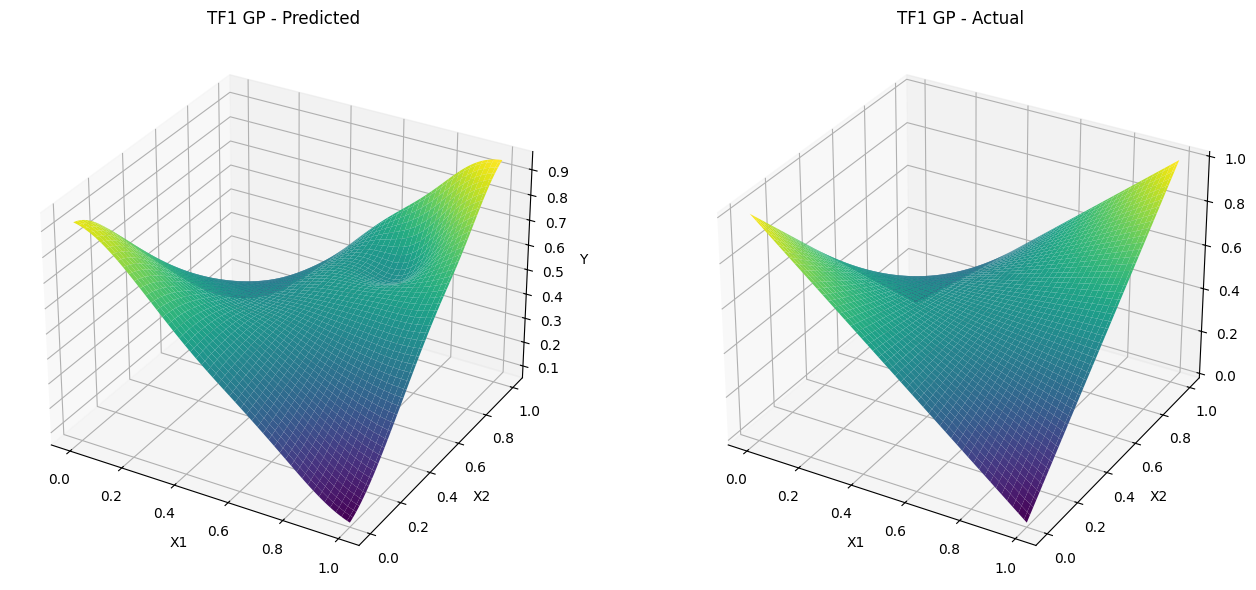

In [22]:
# Wrapper for GP model to add predict method for em.evaluate compatibility
class GPModel:
    """Wrapper for Gaussian Process model for compatibility with em.evaluate()."""
    
    def __init__(self, model, likelihood):
        self.model = model
        self.likelihood = likelihood
    
    def predict(self, X):
        """Make predictions with the GP model."""
        X_tensor = torch.tensor(X, dtype=torch.float64)
        pred_mean, pred_std = gp.predict(self.model, self.likelihood, X_tensor)
        return pred_mean.cpu().numpy()


# TF1 GP Model Training
print("=" * 70)
print("Training Gaussian Process baseline on TF1")
print("=" * 70)

# Convert to torch tensors with float64
X_train_gp = torch.tensor(tf1_x_train, dtype=torch.float64)
y_train_gp = torch.tensor(tf1_y_train, dtype=torch.float64)
X_test_gp = torch.tensor(tf1_x_test, dtype=torch.float64)
y_test_gp = torch.tensor(tf1_y_test, dtype=torch.float64)

# Initialize GP model and likelihood
tf1_gp_model, tf1_gp_likelihood = gp.init_gp(
    X_train_gp,
    y_train_gp,
    kernel=create_matern_kernel(tf1_x_train.shape[1]),
    num_inducing=388
)

# Train GP model
print("\nTraining GP...")
tf1_gp_model, tf1_gp_likelihood = gp.train_gp(
    tf1_gp_model,
    tf1_gp_likelihood,
    X_train_gp,
    y_train_gp,
    num_iters=500,
    lr=0.002930
)

# Evaluate GP model
print("\nEvaluating GP...")
tf1_gp_results = em.evaluate(
    GPModel(tf1_gp_model, tf1_gp_likelihood),
    tf1_x_train, tf1_y_train, tf1_x_test, tf1_y_test
)

print_results(tf1_gp_results)

# Make predictions for visualization
tf1_gp_y_test_pred, _ = gp.predict(tf1_gp_model, tf1_gp_likelihood, X_test_gp)
tf1_gp_y_test_pred = tf1_gp_y_test_pred.cpu().numpy()

plot_3d_surface("TF1 GP", tf1_x_test, tf1_y_test, tf1_gp_y_test_pred)

### SGKAN

### SGKAN (Surrogate-Guided KAN) - Hyperparameter Optimization

In [ ]:
def objective_sgkan(trial, X_train, y_train, X_test, y_test, kernel=None, lr=0.001, num_inducing=400, num_iters=500, n_splits=5):
    """
    Objective function for Optuna to find the best SGKAN layer configuration with K-Fold CV.
    
    Uses K-Fold Cross-Validation on training data to evaluate hyperparameter sets.
    Searches over SGKAN layer width, M (pair samples), G (grid), and T (interior points).
    GP hyperparameters are passed as arguments.

    Args:
        trial: Optuna trial object
        X_train, y_train: Training data
        X_test, y_test: Test data for final evaluation
        kernel: GPyTorch kernel for GP (default: Matérn kernel with ARD)
        lr: Learning rate for GP training (default: 0.002930)
        num_inducing: Number of inducing points for sparse GP (default: 388)
        num_iters: Number of training iterations for GP (default: 500)
        n_splits: Number of folds for cross-validation (default: 5)

    Returns:
        float: Average validation RMSE across all folds (what Optuna minimizes)
    """
    # Default kernel if not specified
    if kernel is None:
        kernel = create_matern_kernel(X_train.shape[1])
    
    # Suggest SGKAN hyperparameters
    width = trial.suggest_int("width", 32, 200)  # Layer width. TODO: increase boundary
    M = trial.suggest_int("M", 500, 1000)  # Number of candidate pairs
    G = trial.suggest_int("G", 25, 100)  # Grid size for edge functions
    T = trial.suggest_int("T", 5, 50)  # Interior points between pairs
    
    # Layer configuration with suggested hyperparameters
    layer_config = [{"width": width, "M": M, "G": G, "T": T}]
    
    # K-Fold Cross-Validation on training data
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    fold_val_rmses = []
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
        # Split into fold train/validation (ensure numpy arrays)
        X_fold_train = X_train[train_idx]
        y_fold_train = y_train[train_idx]
        X_fold_val = X_train[val_idx]
        y_fold_val = y_train[val_idx]
        
        # Build and train SGKAN with suggested hyperparameters
        sgkan_layers, sgkan_W_out = fit_sgkan(
            X_fold_train, y_fold_train, layer_config,
            activation=torch.tanh,
            kernel=kernel,
            lr=lr, num_inducing=num_inducing, num_iters=num_iters
        )
        
        # Evaluate on this fold's validation set
        sgkan_pred_val = sgkan.predict_sgkan(sgkan_layers, sgkan_W_out, X_fold_val, activation=torch.tanh)
        rmse = em.compute_rmse(
            torch.tensor(sgkan_pred_val.flatten(), dtype=torch.float64),
            torch.tensor(y_fold_val.flatten(), dtype=torch.float64)
        ).item()
        fold_val_rmses.append(rmse)
    
    # Average validation RMSE across all folds (what Optuna minimizes)
    avg_val_rmse = float(np.mean(fold_val_rmses))
    
    sgkan_layers_final, sgkan_W_out_final = fit_sgkan(
        X_train, y_train, layer_config,
        activation=torch.tanh,
        kernel=kernel,
        lr=lr, num_inducing=num_inducing, num_iters=num_iters
    )
    
    sgkan_pred_test = sgkan.predict_sgkan(sgkan_layers_final, sgkan_W_out_final, X_test, activation=torch.tanh)
    test_rmse = em.compute_rmse(
        torch.tensor(sgkan_pred_test.flatten(), dtype=torch.float64),
        torch.tensor(y_test.flatten(), dtype=torch.float64)
    ).item()
    
    # Store test RMSE as user attribute
    trial.set_user_attr("test_rmse", test_rmse)
    trial.set_user_attr("val_rmse", avg_val_rmse)
    
    return avg_val_rmse


# # --- Study setup with K-Fold CV -----------------------------------------------
# print("=" * 70)
# print("Optimizing SGKAN hyperparameters with 5-Fold Cross-Validation on TF1")
# print("=" * 70)

# study = optuna.create_study(direction='minimize')

# study.optimize(
#     lambda trial: objective_sgkan(trial, tf1_x_train, tf1_y_train, tf1_x_test, tf1_y_test,
#                                   n_splits=5, num_inducing=388, lr=0.002930, num_iters=500, kernel=create_matern_kernel(tf1_x_train.shape[1])),
#     n_trials=10,
#     show_progress_bar=True,
# )

# # --- Results ---------------------------------------------------------------
# print("\n" + "=" * 70)
# print("Best trial results:")
# print("=" * 70)
# print(f"Best CV Validation RMSE: {study.best_value:.6f}")
# best_test_rmse = study.best_trial.user_attrs.get("test_rmse", "N/A")
# print(f"Best Test RMSE:          {best_test_rmse:.6f}" if isinstance(best_test_rmse, float) else f"Best Test RMSE: {best_test_rmse}")
# print(f"Best hyperparameters:")
# print(f"  width:  {study.best_params['width']}")
# print(f"  M:      {study.best_params['M']}")
# print(f"  G:      {study.best_params['G']}")
# print(f"  T:      {study.best_params['T']}")

# # Display all trials
# trials_df = study.trials_dataframe()
# print(f"\nAll {len(trials_df)} trials:")
# print(trials_df[['number', 'value', 'params_width', 'params_M', 'params_G', 'params_T', 'user_attrs_test_rmse']].to_string())

# trials_df = trials_df.rename(columns={
#     "user_attrs_test_rmse": "test_rmse",
#     "user_attrs_val_rmse": "val_rmse",
# })
# trials_df['duration'] = trials_df['duration'].dt.total_seconds()
# trials_df.to_csv("data/tf1_sgkan_optuna_search.csv")

In [25]:
tf1_sgkan_optuna_search = pd.read_csv("data/tf1_sgkan_optuna_search.csv")
tf1_sgkan_optuna_search.sort_values("val_rmse")

,Unnamed: 0,number,value,datetime_start,datetime_complete,duration,params_G,params_M,params_T,params_width,test_rmse,val_rmse,state
2,2,2,0.003401,2026-06-05 18:22:55.498973,2026-06-05 18:26:18.187928,202.688955,81,954,20,197,0.004079,0.003401,COMPLETE
8,8,8,0.003676,2026-06-05 18:42:30.275175,2026-06-05 18:45:50.492722,200.217547,28,640,10,180,0.003858,0.003676,COMPLETE
6,6,6,0.004157,2026-06-05 18:36:00.069623,2026-06-05 18:39:13.710430,193.640807,79,713,16,151,0.004367,0.004157,COMPLETE
7,7,7,0.004469,2026-06-05 18:39:13.712126,2026-06-05 18:42:30.273579,196.561453,36,872,25,154,0.004535,0.004469,COMPLETE
0,0,0,0.004739,2026-06-05 18:16:20.396233,2026-06-05 18:19:33.232917,192.836684,65,568,35,138,0.006497,0.004739,COMPLETE
9,9,9,0.005172,2026-06-05 18:45:50.494371,2026-06-05 18:49:00.648707,190.154336,79,873,16,122,0.005353,0.005172,COMPLETE
1,1,1,0.005377,2026-06-05 18:19:33.234469,2026-06-05 18:22:55.497176,202.262707,75,842,12,117,0.005617,0.005377,COMPLETE
4,4,4,0.005513,2026-06-05 18:29:30.446829,2026-06-05 18:32:48.537992,198.091163,74,626,41,125,0.004730,0.005513,COMPLETE
3,3,3,0.010231,2026-06-05 18:26:18.189758,2026-06-05 18:29:30.445293,192.255535,57,973,33,59,0.014998,0.010231,COMPLETE
5,5,5,0.011485,2026-06-05 18:32:48.540041,2026-06-05 18:36:00.066591,191.526550,56,865,49,61,0.009057,0.011485,COMPLETE


In [26]:
# TF1 SGKAN layer configuration
# Single layer with width=5 to match KAN architecture
tf1_sgkan_layer_configs = [
    {"width": 197, "M": 954, "G": 81, "T": 20}
]

# Kernel options (available for use with gp.init_gp):
# - Default (RBF with ARD): passed implicitly
# - Custom Matern: kernel = create_matern_kernel(tf1_x_train.shape[1])
# - Custom RBF: kernel = create_rbf_kernel(tf1_x_train.shape[1])

# Train TF1 SGKAN (currently uses default RBF kernel)
# To use custom kernel, modify sgkan.build_sgkan to accept kernel parameter
tf1_sgkan_layers, tf1_sgkan_W_out = fit_sgkan(
    tf1_x_train, tf1_y_train, 
    tf1_sgkan_layer_configs,
    num_inducing=388,
    num_iters=500,
    lr=0.002930,
    activation=torch.tanh,
    kernel=create_matern_kernel(tf1_x_train.shape[1])
)


─── Layer 1 | input: torch.Size([5000, 2]) ───
[DEBUG] Initialized SparseGPModel: X_train.shape=torch.Size([5000, 2]), num_inducing=388
[DEBUG] SparseGPModel and likelihood unfrozen (train mode)
[DEBUG] Training SparseGPModel: 500 iters, lr=0.00293, loss=ELBO
  Iter 100/500, Loss: 0.798389
  Iter 200/500, Loss: 0.765735
  Iter 300/500, Loss: 0.756472
  Iter 400/500, Loss: 0.751573
  Iter 500/500, Loss: 0.749465
[DEBUG] Training complete.
  Lengthscale: tensor([[0.5097, 0.5818]])
  Outputscale: 0.5489
  Noise: 0.693247
  Mean const: 0.2081
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[DEBUG] Scores: min=0.0050, max=1.3794, mean=0.4815
[DEBUG] Probs:  min=0.000011,  max=0.003003,  sum=1.000000
[DEBUG] Selected 197 pairs from 954 candidates
[DEBUG] Unique pairs selected: 176 / 197
[DEBUG] x_segments shape:     torch.Size([197, 81, 2])
[DEBUG] edge_functions shape: torch.Size([197, 81])
[DEBUG] Value range: [0.1331, 0.8753]
[DEBUG] H shape: torch.Size([5000, 197])
[DEBUG] H val

In [27]:
# Wrapper for SGKAN model to add predict method for em.evaluate compatibility
class SGKANModel:
    def __init__(self, layers, W_out, activation=torch.tanh):
        self.layers = layers
        self.W_out = W_out
        self.activation = activation
    
    def predict(self, X):
        X_tensor = torch.tensor(X, dtype=torch.float64)
        return sgkan.predict_sgkan(self.layers, self.W_out, X_tensor, activation=self.activation).detach().numpy()

tf1_sgkan_results = em.evaluate(
    SGKANModel(tf1_sgkan_layers, tf1_sgkan_W_out, activation=torch.tanh),
    tf1_x_train, tf1_y_train, tf1_x_test, tf1_y_test
)

[DEBUG] H shape: torch.Size([5000, 197])
[DEBUG] H value range: [0.1331, 0.8753]
[DEBUG] H rank (approx): 176
[DEBUG] H shape: torch.Size([10000, 197])
[DEBUG] H value range: [0.1331, 0.8753]
[DEBUG] H rank (approx): 176


In [28]:
print_results(tf1_sgkan_results)

Metric          Train                Test                
-------------------------------------------------------
MAE             2.716531e-03         2.931872e-03        
RMSE            3.631928e-03         4.073612e-03        


In [31]:
tf1_sgkan_y_test_pred = predict_sgkan(tf1_sgkan_layers, tf1_sgkan_W_out, tf1_x_test, activation=torch.tanh)

[DEBUG] H shape: torch.Size([10000, 197])
[DEBUG] H value range: [0.1331, 0.8753]
[DEBUG] H rank (approx): 176
✓ Prediction completed in 0.0778 seconds


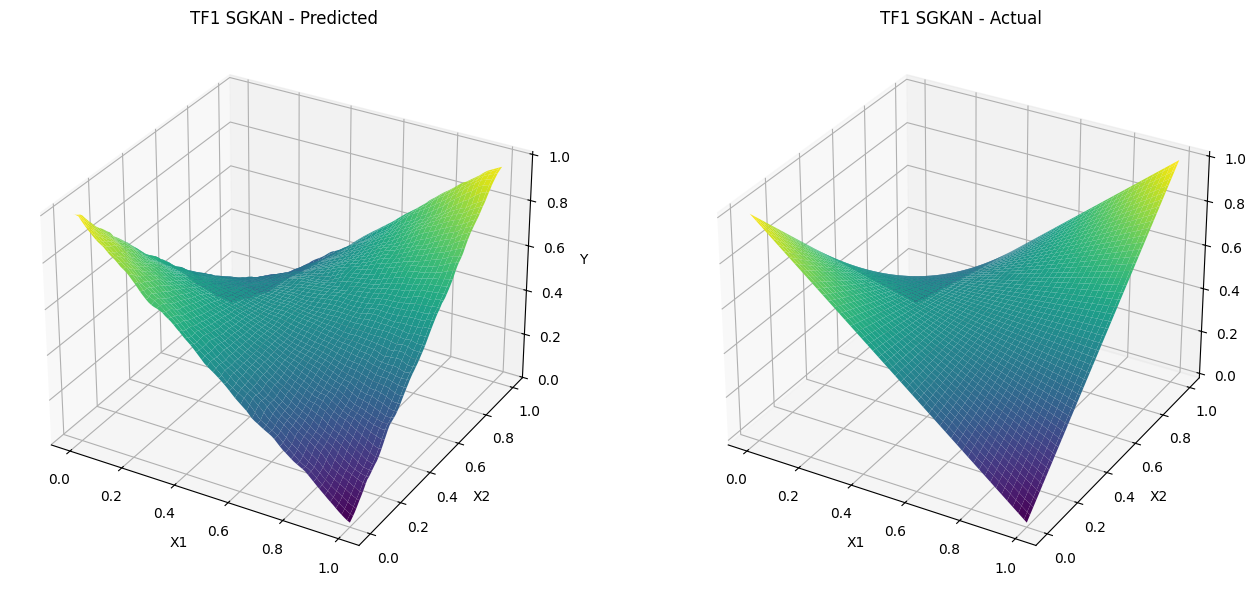

In [32]:
plot_3d_surface("TF1 SGKAN", tf1_x_test, tf1_y_test, tf1_sgkan_y_test_pred)

## TF2 Results

### HKAN

In [33]:
# Load tf2 dataset
tf2 = load_dataset("TF2")
tf2_x_train, tf2_x_test, tf2_y_train, tf2_y_test = tf2["train_input"], tf2["test_input"], tf2["train_label"], tf2["test_label"]

In [34]:
print("TF2 X_train shape:", tf2_x_train.shape)
print("TF2 X_test shape:", tf2_x_test.shape)
print("TF2 y_train range:", tf2_y_train.min(), tf2_y_train.max())
print("TF2 y_train mean:", tf2_y_train.mean())

TF2 X_train shape: (5000, 2)
TF2 X_test shape: (10000, 2)
TF2 y_train range: -0.10303 1.1454
TF2 y_train mean: 0.48207401874000005


In [35]:
# TF2 model params
tf2_model_params = [
    {
        "layer": 0,
        "n_vars_out": 48,
        "basis_fn": Tanh(s=22),
        "n_basis": 17,
        "centers": "random",
        "regressor": Ridge(alpha=0.1),
    },
    {
        "layer": 1,
        "n_vars_out": 11,
        "basis_fn": Softplus(s=18),
        "n_basis": 21,
        "centers": "random_data_points",
        "regressor": Ridge(alpha=1),
    },
    {
        "layer": 2,
        "n_vars_out": 1,
        "basis_fn": Identity(),
        # Default configuration
        "n_basis": 10,
        "centers": "random",
        "regressor": Ridge(),
    }
]
tf2_model = build_hkan_from_params(tf2_model_params)
tf2_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('expanding_layer_0', ...), ('connecting_layer_0', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,n_vars_out,48
,n_basis,17
,centers,'random'
,basis_fn,<hkan.hkan.Ta...t 0x16b846a10>
,base_regressor,Ridge(alpha=0.1)
,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",0.1
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True


In [36]:
# Fit HKAN
fit_hkan(tf2_model, tf2_x_train, tf2_y_train)
tf2_results = em.evaluate(
    tf2_model,
    tf2_x_train, tf2_y_train, tf2_x_test, tf2_y_test
)

Fitting connecting regressors: 100%|██████████| 1/1 [00:00<00:00, 484.33it/s]



✓ Training completed in 2.4783 seconds


In [37]:
print_results(tf2_results)

Metric          Train                Test                
-------------------------------------------------------
MAE             1.008521e-01         1.348625e-02        
RMSE            1.163214e-01         1.698008e-02        


In [38]:
tf2_y_test_pred = predict_hkan(tf2_model, tf2_x_test)

✓ Prediction completed in 1.8485 seconds


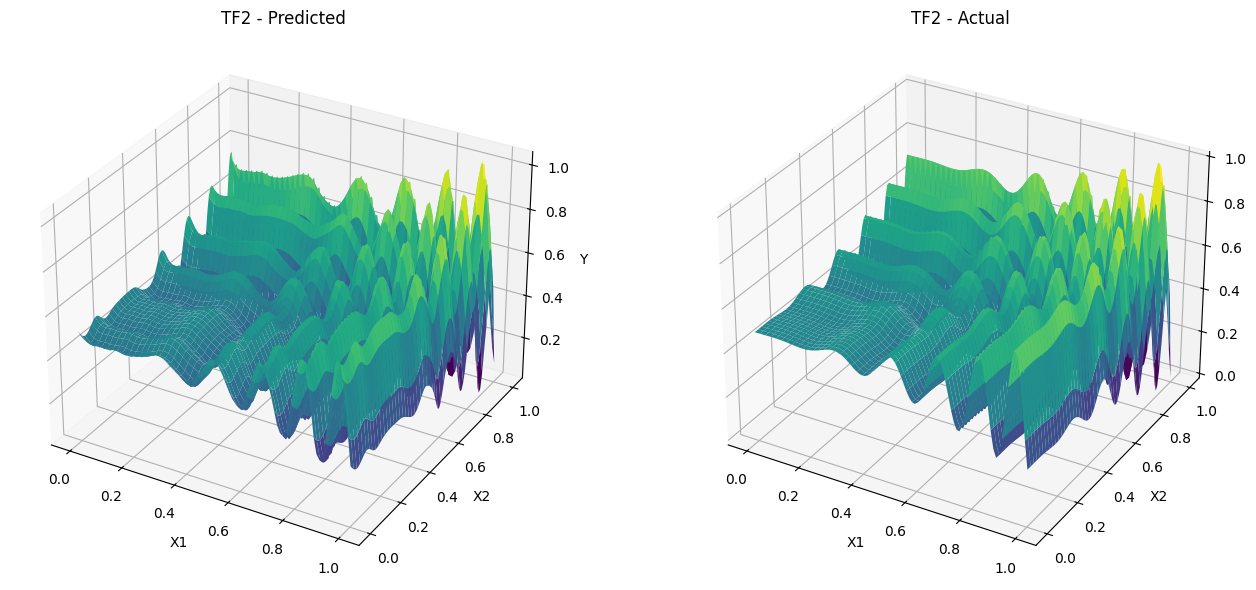

In [39]:
plot_3d_surface("TF2", tf2_x_test, tf2_y_test, tf2_y_test_pred)

### KAN

In [40]:
# # --- Study setup with K-Fold CV -----------------------------------------------
# print("=" * 70)
# print("Optimizing KAN architecture with 5-Fold Cross-Validation on TF2")
# print("=" * 70)

# study = optuna.create_study(
#     direction='minimize',
#     sampler=optuna.samplers.GridSampler(
#         {"width_idx": list(range(10))}  # Exhaustive over all 10 architectures
#     ),
# )

# n = tf2_x_train.shape[1]
# width_options = [
#     [n, 1], [n, 2, 1], [n, n+1, 1], [n, 2*n+1, 1], [n, 2, 2, 1],
#     [n, n+1, 2, 1], [n, 2*n+1, 2, 1], [n, n+1, n+1, 1],
#     [n, 2*n+1, n+1, 1], [n, 2*n+1, 2*n+1, 1],
# ]

# study.optimize(
#     lambda trial: objective_kan(
#         trial, tf2_x_train, tf2_y_train, tf2_x_test, tf2_y_test, n_splits=5
#     ),
#     n_trials=10,
#     show_progress_bar=True,
# )

# # --- Results ---------------------------------------------------------------
# print("\n" + "=" * 70)
# print("Best trial results:")
# print("=" * 70)
# print(f"Best CV Validation RMSE: {study.best_value:.6f}")
# best_test_rmse = study.best_trial.user_attrs.get("test_rmse", "N/A")
# print(f"Best Test RMSE:          {best_test_rmse:.6f}" if isinstance(best_test_rmse, float) else f"Best Test RMSE: {best_test_rmse}")
# print(f"Best width_idx:          {study.best_params['width_idx']}")
# print(f"Best architecture:       {width_options[study.best_params['width_idx']]}")

# # Display all trials with both validation and test RMSE
# trials_df = study.trials_dataframe()
# print(f"\nAll {len(trials_df)} trials:")
# print(trials_df[['number', 'value', 'params_width_idx', 'user_attrs_val_rmse', 'user_attrs_test_rmse']].to_string())

# trials_df = trials_df.rename(columns={
#     "user_attrs_test_rmse": "test_rmse",
#     "user_attrs_val_rmse": "val_rmse",
# })
# trials_df['duration'] = trials_df['duration'].dt.total_seconds()
# trials_df.to_csv("data/tf2_kan_optuna_search.csv")

In [41]:
tf2_kan_optuna_search = pd.read_csv("data/tf2_kan_optuna_search.csv")
tf2_kan_optuna_search.sort_values("val_rmse")

,Unnamed: 0,number,value,datetime_start,datetime_complete,duration,params_width_idx,test_rmse,val_rmse,system_attrs_grid_id,system_attrs_search_space,state
8,8,8,0.173447,2026-06-06 14:28:14.296919,2026-06-06 14:29:06.032328,51.735409,0,0.129826,0.173447,8,"{'width_idx': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]}",COMPLETE
7,7,7,0.197938,2026-06-06 14:27:14.810196,2026-06-06 14:28:14.295359,59.485163,3,0.181680,0.197938,7,"{'width_idx': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]}",COMPLETE
5,5,5,0.198356,2026-06-06 14:25:04.298856,2026-06-06 14:26:10.525607,66.226751,6,0.130486,0.198356,5,"{'width_idx': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]}",COMPLETE
2,2,2,0.214038,2026-06-06 14:21:48.553615,2026-06-06 14:22:50.901223,62.347608,4,0.239839,0.214038,2,"{'width_idx': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]}",COMPLETE
0,0,0,0.220154,2026-06-06 14:19:44.257425,2026-06-06 14:20:45.831491,61.574066,2,0.134638,0.220154,0,"{'width_idx': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]}",COMPLETE
4,4,4,0.242890,2026-06-06 14:24:05.735925,2026-06-06 14:25:04.297333,58.561408,1,0.132069,0.242890,4,"{'width_idx': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]}",COMPLETE
1,1,1,0.255157,2026-06-06 14:20:45.833326,2026-06-06 14:21:48.551971,62.718645,8,10.841902,0.255157,1,"{'width_idx': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]}",COMPLETE
6,6,6,0.313805,2026-06-06 14:26:10.527195,2026-06-06 14:27:14.808561,64.281366,7,0.488357,0.313805,6,"{'width_idx': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]}",COMPLETE
3,3,3,2.014279,2026-06-06 14:22:50.902881,2026-06-06 14:24:05.734033,74.831152,9,0.431603,2.014279,3,"{'width_idx': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]}",COMPLETE
9,9,9,4.529024,2026-06-06 14:29:06.033946,2026-06-06 14:30:14.305632,68.271686,5,0.473081,4.529024,9,"{'width_idx': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]}",COMPLETE


In [42]:
# Create TF2 KAN model with architecture
tf2_kan_model = build_kan(width=[2, 1], grid=3, k=3, seed=42)

checkpoint directory created: ./model
saving model version 0.0


In [43]:
# Train TF2 KAN model
fit_kan(tf2_kan_model, tf2_x_train, tf2_y_train, tf2_x_test, tf2_y_test, steps=100, opt="Adam", lamb=1e-3)

tf2_kan_results = em.evaluate(
    KANModel(tf2_kan_model),
    tf2_x_train, tf2_y_train, tf2_x_test, tf2_y_test
)

| train_loss: 1.74e-01 | test_loss: 1.30e-01 | reg: 3.84e-01 | : 100%|█| 100/100 [00:21<00:00,  4.61

saving model version 0.1

✓ Training completed in 21.7224 seconds


In [44]:
print_results(tf2_kan_results)

Metric          Train                Test                
-------------------------------------------------------
MAE             1.403017e-01         9.761542e-02        
RMSE            1.734280e-01         1.298259e-01        


In [45]:
tf2_y_test_pred_kan = predict_kan(tf2_kan_model, tf2_x_test)

✓ Prediction completed in 0.0056 seconds


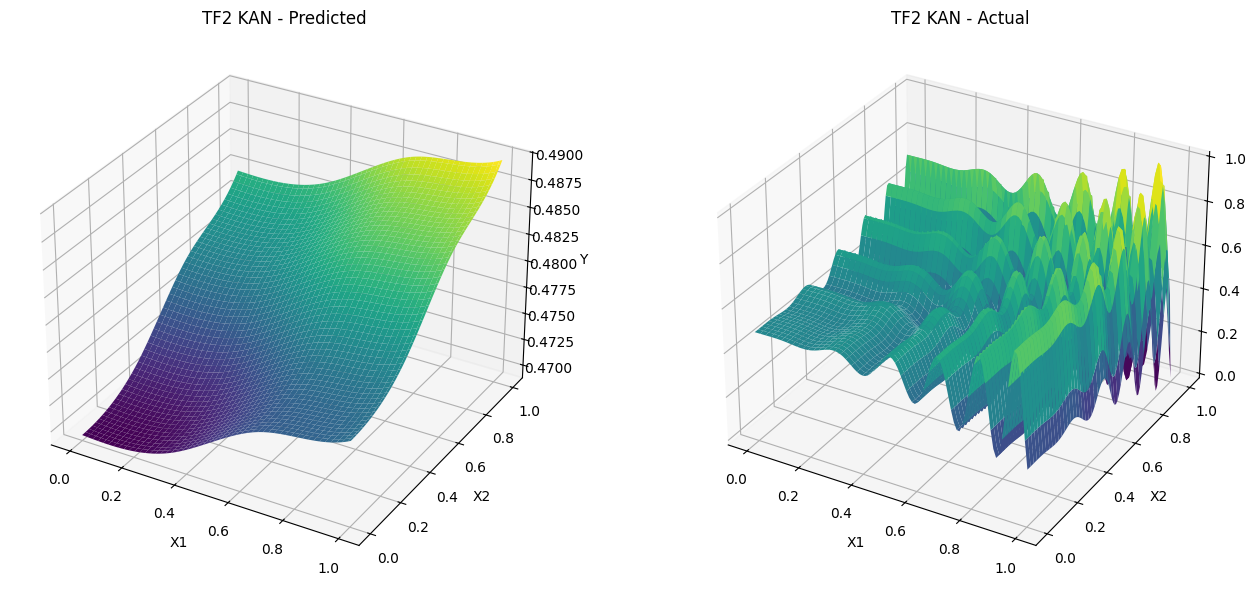

In [46]:
plot_3d_surface("TF2 KAN", tf2_x_test, tf2_y_test, tf2_y_test_pred_kan)

### GP (Gaussian Process Baseline)

In [47]:
# # --- Study setup with K-Fold CV -----------------------------------------------
# print("=" * 70)
# print("Optimizing GP hyperparameters with 5-Fold Cross-Validation on TF2")
# print("=" * 70)

# study = optuna.create_study(direction='minimize')

# study.optimize(
#     lambda trial: objective_gp(trial, tf2_x_train, tf2_y_train, tf2_x_test, tf2_y_test, n_splits=5),
#     n_trials=10,
#     show_progress_bar=True,
# )

# # --- Results ---------------------------------------------------------------
# print("\n" + "=" * 70)
# print("Best trial results:")
# print("=" * 70)
# print(f"Best CV Validation RMSE: {study.best_value:.6f}")
# best_test_rmse = study.best_trial.user_attrs.get("test_rmse", "N/A")
# print(f"Best Test RMSE:          {best_test_rmse:.6f}" if isinstance(best_test_rmse, float) else f"Best Test RMSE: {best_test_rmse}")
# print(f"Best hyperparameters:")
# print(f"  lr:              {study.best_params['lr']:.6f}")
# print(f"  kernel:          {study.best_params['kernel']}")
# print(f"  num_inducing:    {study.best_params['num_inducing']}")

# # Display all trials
# trials_df = study.trials_dataframe()
# print(f"\nAll {len(trials_df)} trials:")
# print(trials_df[['number', 'value', 'params_lr', 'params_kernel', 'params_num_inducing', 'user_attrs_test_rmse']].to_string())

# trials_df = trials_df.rename(columns={
#     "user_attrs_test_rmse": "test_rmse",
#     "user_attrs_val_rmse": "val_rmse",
# })
# trials_df['duration'] = trials_df['duration'].dt.total_seconds()
# trials_df.to_csv("data/tf2_gp_optuna_search.csv")

In [74]:
tf2_gp_optuna_search = pd.read_csv("data/tf2_gp_optuna_search.csv")
tf2_gp_optuna_search.sort_values("val_rmse")

,Unnamed: 0,number,value,datetime_start,datetime_complete,duration,params_kernel,params_lr,params_num_inducing,test_rmse,val_rmse,state
7,7,7,0.173309,2026-06-06 14:50:10.236350,2026-06-06 14:53:04.019576,173.783226,matern,0.021981,333,0.129775,0.173309,COMPLETE
3,3,3,0.173404,2026-06-06 14:43:14.261672,2026-06-06 14:44:54.632552,100.370880,matern,0.004080,215,0.130036,0.173404,COMPLETE
0,0,0,0.173413,2026-06-06 14:34:57.038574,2026-06-06 14:36:03.783801,66.745227,rbf,0.030385,188,0.129803,0.173413,COMPLETE
9,9,9,0.173509,2026-06-06 14:54:58.955642,2026-06-06 14:57:15.613998,136.658356,matern,0.077325,273,0.129804,0.173509,COMPLETE
6,6,6,0.174982,2026-06-06 14:49:13.035226,2026-06-06 14:50:10.234770,57.199544,rbf,0.002104,151,0.133122,0.174982,COMPLETE
1,1,1,0.222643,2026-06-06 14:36:03.786187,2026-06-06 14:39:33.174631,209.388444,rbf,0.000339,488,0.187834,0.222643,COMPLETE
4,4,4,0.228913,2026-06-06 14:44:54.634270,2026-06-06 14:47:51.393970,176.759700,rbf,0.000289,421,0.211219,0.228913,COMPLETE
2,2,2,0.261642,2026-06-06 14:39:33.176405,2026-06-06 14:43:14.259951,221.083546,rbf,0.000229,485,0.235471,0.261642,COMPLETE
5,5,5,0.294178,2026-06-06 14:47:51.396169,2026-06-06 14:49:13.033466,81.637297,rbf,0.000205,226,0.256593,0.294178,COMPLETE
8,8,8,0.394039,2026-06-06 14:53:04.021362,2026-06-06 14:54:58.954030,114.932668,rbf,0.000106,336,0.378036,0.394039,COMPLETE


[DEBUG] Initialized SparseGPModel: X_train.shape=torch.Size([5000, 2]), num_inducing=333

Training GP...
[DEBUG] SparseGPModel and likelihood unfrozen (train mode)
[DEBUG] Training SparseGPModel: 500 iters, lr=0.021981, loss=ELBO
  Iter 100/500, Loss: 0.762906
  Iter 200/500, Loss: 0.761307
  Iter 300/500, Loss: 0.760688
  Iter 400/500, Loss: 0.760310
  Iter 500/500, Loss: 0.760043
[DEBUG] Training complete.
  Lengthscale: tensor([[1.6916, 1.3647]])
  Outputscale: 0.3914
  Noise: 0.693247
  Mean const: 0.2671
[DEBUG] SparseGPModel and likelihood frozen (eval mode)

Evaluating GP...
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
Metric          Train                Test                
-------------------------------------------------------
MAE             1.399924e-01         9.765767e-02        
RMSE            1.729614e-01         1.299437e-01        
[DEBUG] SparseGPModel and likelihood frozen (eval mode)


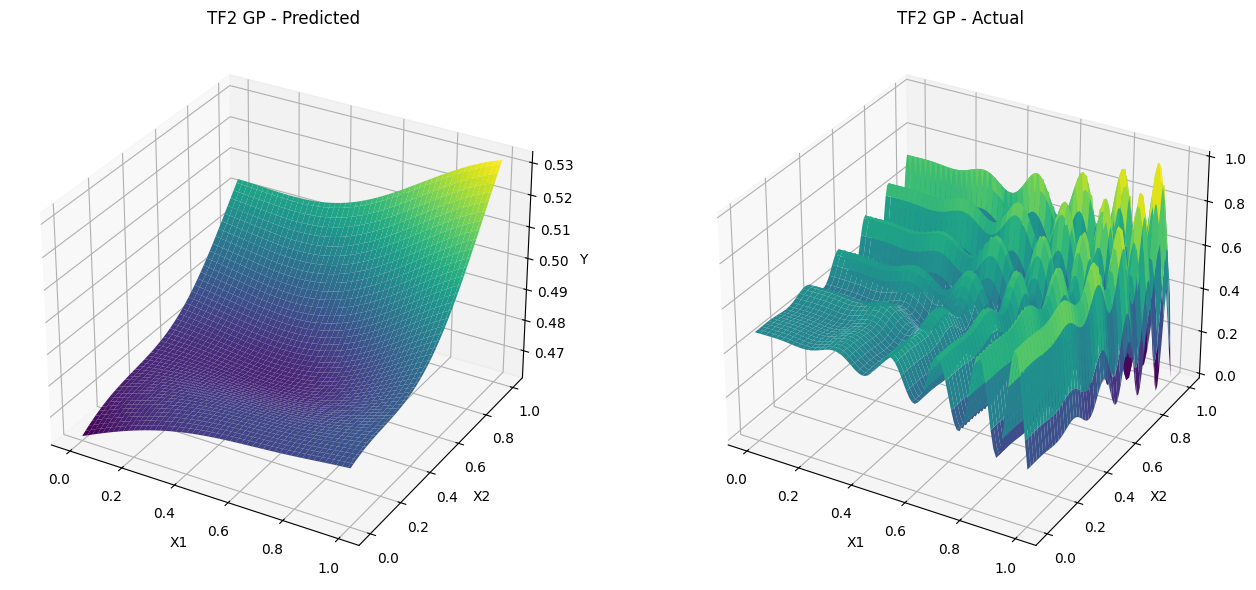

In [48]:
# Convert to torch tensors with float64
X_train_gp_tf2 = torch.tensor(tf2_x_train, dtype=torch.float64)
y_train_gp_tf2 = torch.tensor(tf2_y_train, dtype=torch.float64)
X_test_gp_tf2 = torch.tensor(tf2_x_test, dtype=torch.float64)
y_test_gp_tf2 = torch.tensor(tf2_y_test, dtype=torch.float64)

# Initialize GP model and likelihood
tf2_gp_model, tf2_gp_likelihood = gp.init_gp(
    X_train_gp_tf2,
    y_train_gp_tf2,
    kernel=create_matern_kernel(tf2_x_train.shape[1]),
    num_inducing=333
)

# Train GP model
print("\nTraining GP...")
tf2_gp_model, tf2_gp_likelihood = gp.train_gp(
    tf2_gp_model,
    tf2_gp_likelihood,
    X_train_gp_tf2,
    y_train_gp_tf2,
    num_iters=500,
    lr=0.021981
)

# Evaluate GP model
print("\nEvaluating GP...")
tf2_gp_results = em.evaluate(
    GPModel(tf2_gp_model, tf2_gp_likelihood),
    tf2_x_train, tf2_y_train, tf2_x_test, tf2_y_test
)

print_results(tf2_gp_results)

# Make predictions for visualization
tf2_gp_y_test_pred, _ = gp.predict(tf2_gp_model, tf2_gp_likelihood, X_test_gp_tf2)
tf2_gp_y_test_pred = tf2_gp_y_test_pred.cpu().numpy()

plot_3d_surface("TF2 GP", tf2_x_test, tf2_y_test, tf2_gp_y_test_pred)

### SGKAN

In [49]:
# # --- Study setup with K-Fold CV -----------------------------------------------
# print("=" * 70)
# print("Optimizing SGKAN hyperparameters with 5-Fold Cross-Validation on TF2")
# print("=" * 70)


# study = optuna.create_study(direction='minimize')

# study.optimize(
#     lambda trial: objective_sgkan(
#         trial, tf2_x_train, tf2_y_train, tf2_x_test, tf2_y_test,
#         kernel=create_matern_kernel(tf2_x_train.shape[1]), lr=0.021981, num_inducing=333, num_iters=500,
#         n_splits=5
#     ),
#     n_trials=10,
#     show_progress_bar=True,
# )

# # --- Results ---------------------------------------------------------------
# print("\n" + "=" * 70)
# print("Best trial results:")
# print("=" * 70)
# print(f"Best CV Validation RMSE: {study.best_value:.6f}")
# best_test_rmse = study.best_trial.user_attrs.get("test_rmse", "N/A")
# print(f"Best Test RMSE:          {best_test_rmse:.6f}" if isinstance(best_test_rmse, float) else f"Best Test RMSE: {best_test_rmse}")
# print(f"Best hyperparameters:")
# print(f"  width:  {study.best_params['width']}")
# print(f"  M:      {study.best_params['M']}")
# print(f"  G:      {study.best_params['G']}")
# print(f"  T:      {study.best_params['T']}")

# # Display all trials
# trials_df = study.trials_dataframe()
# print(f"\nAll {len(trials_df)} trials:")
# print(trials_df[['number', 'value', 'params_width', 'params_M', 'params_G', 'params_T', 'user_attrs_test_rmse']].to_string())

# trials_df = trials_df.rename(columns={
#     "user_attrs_test_rmse": "test_rmse",
#     "user_attrs_val_rmse": "val_rmse",
# })
# trials_df['duration'] = trials_df['duration'].dt.total_seconds()
# trials_df.to_csv("data/tf2_sgkan_optuna_search.csv")

In [50]:
tf2_sgkan_optuna_search = pd.read_csv("data/tf2_sgkan_optuna_search.csv")
tf2_sgkan_optuna_search.sort_values("val_rmse")

,Unnamed: 0,number,value,datetime_start,datetime_complete,duration,params_G,params_M,params_T,params_width,test_rmse,val_rmse,state
9,9,9,0.159091,2026-06-06 15:43:22.246353,2026-06-06 15:46:06.477350,164.230997,73,988,9,195,0.105243,0.159091,COMPLETE
0,0,0,0.159418,2026-06-06 15:18:12.991211,2026-06-06 15:21:07.347665,174.356454,30,699,42,137,0.126892,0.159418,COMPLETE
7,7,7,0.160271,2026-06-06 15:37:52.398053,2026-06-06 15:40:39.619979,167.221926,27,926,26,122,0.125699,0.160271,COMPLETE
2,2,2,0.160311,2026-06-06 15:24:02.438708,2026-06-06 15:26:46.779405,164.340697,54,580,47,170,0.124121,0.160311,COMPLETE
6,6,6,0.166110,2026-06-06 15:35:12.419482,2026-06-06 15:37:52.396475,159.976993,59,584,39,108,0.125711,0.166110,COMPLETE
3,3,3,0.166121,2026-06-06 15:26:46.781130,2026-06-06 15:29:36.715411,169.934281,83,808,45,93,0.127660,0.166121,COMPLETE
8,8,8,0.167533,2026-06-06 15:40:39.622020,2026-06-06 15:43:22.244825,162.622805,72,701,47,94,0.126344,0.167533,COMPLETE
1,1,1,0.169476,2026-06-06 15:21:07.349397,2026-06-06 15:24:02.437067,175.087670,29,822,12,90,0.128133,0.169476,COMPLETE
4,4,4,0.171288,2026-06-06 15:29:36.717643,2026-06-06 15:32:22.613209,165.895566,51,900,34,101,0.129214,0.171288,COMPLETE
5,5,5,0.172632,2026-06-06 15:32:22.614906,2026-06-06 15:35:12.417667,169.802761,34,754,27,48,0.130188,0.172632,COMPLETE


In [51]:
tf2_sgkan_layer_configs = [
    {"width": 195, "M": 9888, "G": 73, "T": 9}
]

# Train TF2 SGKAN with best hyperparameters
tf2_sgkan_layers, tf2_sgkan_W_out = fit_sgkan(
    tf2_x_train, tf2_y_train, 
    tf2_sgkan_layer_configs,
    num_inducing=333,
    num_iters=500,
    lr=0.021981,
    activation=torch.tanh,
    kernel=create_matern_kernel(tf2_x_train.shape[1])
)


─── Layer 1 | input: torch.Size([5000, 2]) ───
[DEBUG] Initialized SparseGPModel: X_train.shape=torch.Size([5000, 2]), num_inducing=333
[DEBUG] SparseGPModel and likelihood unfrozen (train mode)
[DEBUG] Training SparseGPModel: 500 iters, lr=0.021981, loss=ELBO
  Iter 100/500, Loss: 0.762759
  Iter 200/500, Loss: 0.761337
  Iter 300/500, Loss: 0.760766
  Iter 400/500, Loss: 0.760391
  Iter 500/500, Loss: 0.760116
[DEBUG] Training complete.
  Lengthscale: tensor([[1.4062, 1.5024]])
  Outputscale: 0.3885
  Noise: 0.693247
  Mean const: 0.2737
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[DEBUG] Scores: min=0.0008, max=0.4905, mean=0.1830
[DEBUG] Probs:  min=0.000000,  max=0.000271,  sum=1.000000
[DEBUG] Selected 195 pairs from 9888 candidates
[DEBUG] Unique pairs selected: 194 / 195
[DEBUG] x_segments shape:     torch.Size([195, 73, 2])
[DEBUG] edge_functions shape: torch.Size([195, 73])
[DEBUG] Value range: [0.4592, 0.5266]
[DEBUG] H shape: torch.Size([5000, 195])
[DEBUG] H v

In [52]:
tf2_sgkan_results = em.evaluate(
    SGKANModel(tf2_sgkan_layers, tf2_sgkan_W_out, activation=torch.tanh),
    tf2_x_train, tf2_y_train, tf2_x_test, tf2_y_test
)

[DEBUG] H shape: torch.Size([5000, 195])
[DEBUG] H value range: [0.4592, 0.5266]
[DEBUG] H rank (approx): 194
[DEBUG] H shape: torch.Size([10000, 195])
[DEBUG] H value range: [0.4592, 0.5266]
[DEBUG] H rank (approx): 194


In [53]:
print_results(tf2_sgkan_results)

Metric          Train                Test                
-------------------------------------------------------
MAE             1.117412e-01         6.085692e-02        
RMSE            1.347113e-01         8.214092e-02        


In [54]:
tf2_sgkan_y_test_pred = predict_sgkan(tf2_sgkan_layers, tf2_sgkan_W_out, tf2_x_test, activation=torch.tanh)

[DEBUG] H shape: torch.Size([10000, 195])
[DEBUG] H value range: [0.4592, 0.5266]
[DEBUG] H rank (approx): 194
✓ Prediction completed in 0.0632 seconds


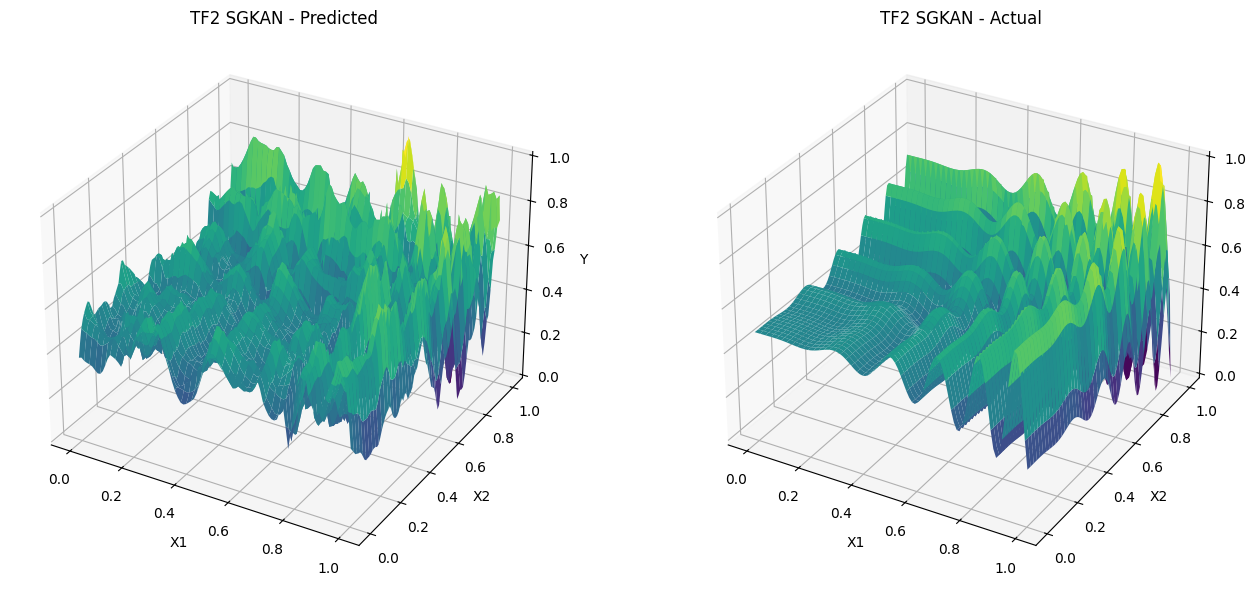

In [55]:
plot_3d_surface("TF2 SGKAN", tf2_x_test, tf2_y_test, tf2_sgkan_y_test_pred)